# Bước 3: So sánh các thuật toán Phân loại (Classification Comparison)

PHÂN TÍCH PHÂN LỚP KHÁCH HÀNG NGÂN HÀNG
Mục tiêu: Dự đoán và phân tích khách hàng có nguy cơ rời bỏ (Churn Prediction)
         sử dụng 3 thuật toán:
1. **Logistic Regression:**: Mô hình phân lớp tuyến tính, sử dụng hàm sigmoid để dự đoán xác suất churn, dễ giải thích và huấn luyện nhanh.
2. **Decision Tree:**: Thuật toán xây dựng cây quyết định phân cấp dựa trên đặc trưng, dễ hiểu và có khả năng xử lý tốt dữ liệu hỗn hợp.
3. **SVM (Support Vector Machine):**: Tìm siêu mặt phẳng tối ưu để phân tách hai lớp churn và không churn, hiệu quả cao với dữ liệu nhiều chiều.
---


# 1. IMPORT THƯ VIỆN & CẤU HÌNH


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, learning_curve, StratifiedKFold
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, roc_curve, confusion_matrix, classification_report,
                             ConfusionMatrixDisplay, precision_recall_curve)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.svm import SVC
from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_classif
import warnings
warnings.filterwarnings('ignore')

# Cấu hình hiển thị
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12
sns.set_theme(style='whitegrid', palette='Set2')


# 2. ĐỌC VÀ KHÁM PHÁ DỮ LIỆU


In [6]:
# Đọc dữ liệu đã được làm sạch
df = pd.read_csv('BankChurners_cleaned.csv')
print("="*70)
print("THÔNG TIN DỮ LIỆU BAN ĐẦU")
print("="*70)
print(f"Kích thước dataset: {df.shape[0]} khách hàng x {df.shape[1]} thuộc tính")
print(f"\nCác cột có sẵn: {list(df.columns[:15])} ...")

# Kiểm tra phân phối biến mục tiêu
print("\n" + "="*70)
print("PHÂN PHỐI BIẾN MỤC TIÊU (Attrition_Flag)")
print("="*70)
churn_counts = df['Attrition_Flag'].value_counts()
churn_pct = df['Attrition_Flag'].value_counts(normalize=True) * 100
for label, count, pct in zip(churn_counts.index, churn_counts.values, churn_pct.values):
    status = "Rời bỏ" if label == 1 else "Trung thành"
    print(f"  {status} (label={label}): {count} khách hàng ({pct:.2f}%)")

THÔNG TIN DỮ LIỆU BAN ĐẦU
Kích thước dataset: 10127 khách hàng x 22 thuộc tính

Các cột có sẵn: ['Attrition_Flag', 'Customer_Age', 'Gender', 'Dependent_count', 'Education_Level', 'Income_Category', 'Card_Category', 'Months_on_book', 'Total_Relationship_Count', 'Months_Inactive_12_mon', 'Contacts_Count_12_mon', 'Credit_Limit', 'Total_Revolving_Bal', 'Avg_Open_To_Buy', 'Total_Amt_Chng_Q4_Q1'] ...

PHÂN PHỐI BIẾN MỤC TIÊU (Attrition_Flag)
  Trung thành (label=0): 8500 khách hàng (83.93%)
  Rời bỏ (label=1): 1627 khách hàng (16.07%)


# 3. LỰA CHỌN ĐẶC TRƯNG CHO PHÂN CỤM

In [7]:
features = [
    'Credit_Limit',              # Hạn mức thẻ tín dụng - năng lực tài chính
    'Total_Revolving_Bal',       # Số dư nợ xoay vòng - khả năng sinh lời
    'Avg_Utilization_Ratio',     # Tỷ lệ sử dụng hạn mức - thói quen chi tiêu
    'Total_Trans_Ct',            # Số lượng giao dịch - mức độ tương tác
    'Total_Amt_Chng_Q4_Q1',      # Tốc độ thay đổi số tiền giao dịch
    'Months_Inactive_12_mon',    # Số tháng không hoạt động
    'Contacts_Count_12_mon',     # Số lần liên hệ chăm sóc
    'Total_Relationship_Count'   # Số lượng sản phẩm đang sử dụng
]

X = df[features].copy()
y = df['Attrition_Flag'].copy()

print("\n" + "="*70)
print("8 ĐẶC TRƯNG HÀNH VI TÀI CHÍNH ĐƯỢC CHỌN")
print("="*70)
for i, f in enumerate(features, 1):
    print(f"  {i}. {f}")

print("\n" + "="*70)
print("THỐNG KÊ MÔ TẢ CÁC ĐẶC TRƯNG")
print("="*70)
display(X.describe())


8 ĐẶC TRƯNG HÀNH VI TÀI CHÍNH ĐƯỢC CHỌN
  1. Credit_Limit
  2. Total_Revolving_Bal
  3. Avg_Utilization_Ratio
  4. Total_Trans_Ct
  5. Total_Amt_Chng_Q4_Q1
  6. Months_Inactive_12_mon
  7. Contacts_Count_12_mon
  8. Total_Relationship_Count

THỐNG KÊ MÔ TẢ CÁC ĐẶC TRƯNG


,Credit_Limit,Total_Revolving_Bal,Avg_Utilization_Ratio,Total_Trans_Ct,Total_Amt_Chng_Q4_Q1,Months_Inactive_12_mon,Contacts_Count_12_mon,Total_Relationship_Count
count,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000
mean,8631.953698,1162.814061,0.274894,64.858695,0.759941,2.341167,2.455317,3.812580
std,9088.776650,814.987335,0.275691,23.472570,0.219207,1.010622,1.106225,1.554408
min,1438.300000,0.000000,0.000000,10.000000,0.000000,0.000000,0.000000,1.000000
25%,2555.000000,359.000000,0.023000,45.000000,0.631000,2.000000,2.000000,3.000000
50%,4549.000000,1276.000000,0.176000,67.000000,0.736000,2.000000,2.000000,4.000000
75%,11067.500000,1784.000000,0.503000,81.000000,0.859000,3.000000,3.000000,5.000000
max,34516.000000,2517.000000,0.999000,139.000000,3.397000,6.000000,6.000000,6.000000


# 4. PHÂN TÍCH TƯƠNG QUAN VÀ TRỰC QUAN HÓA

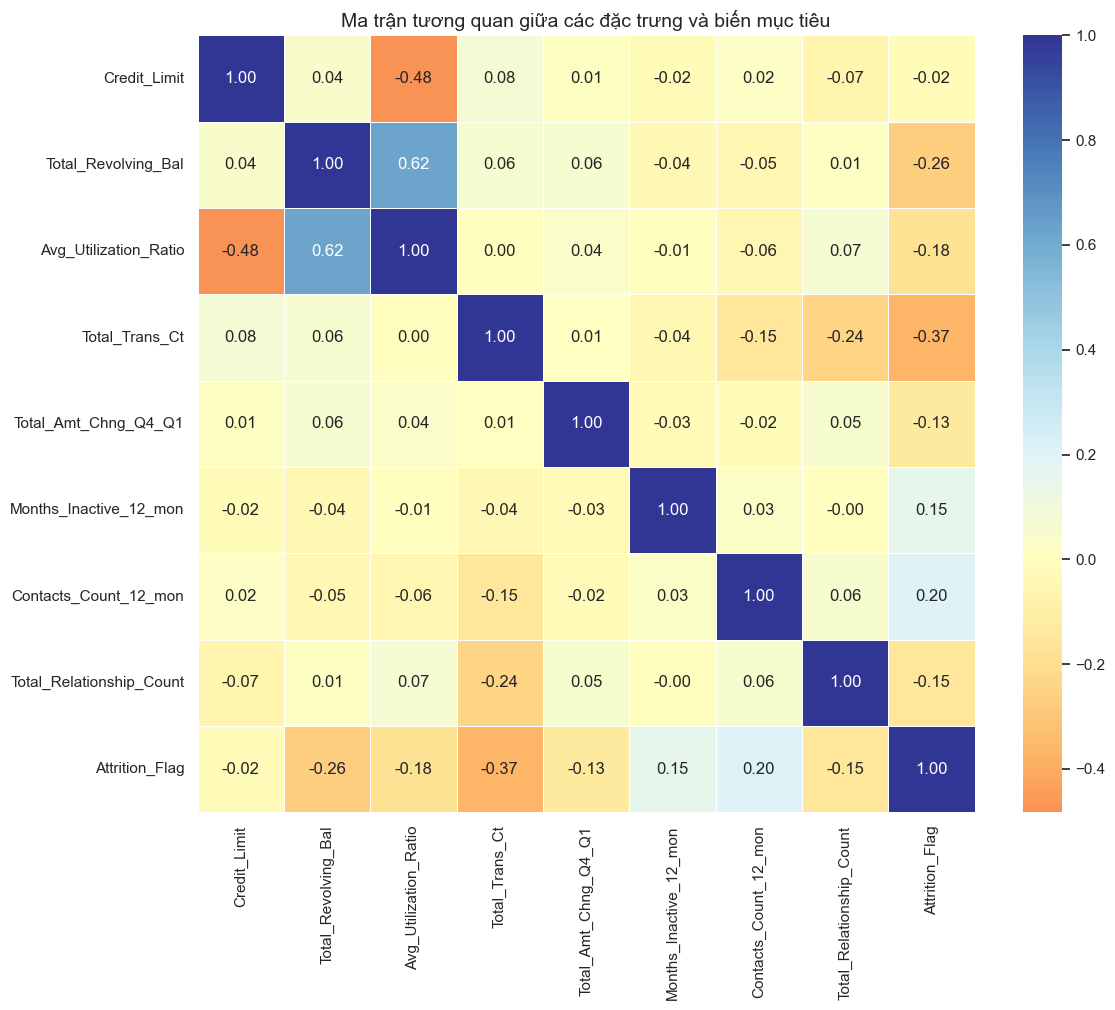

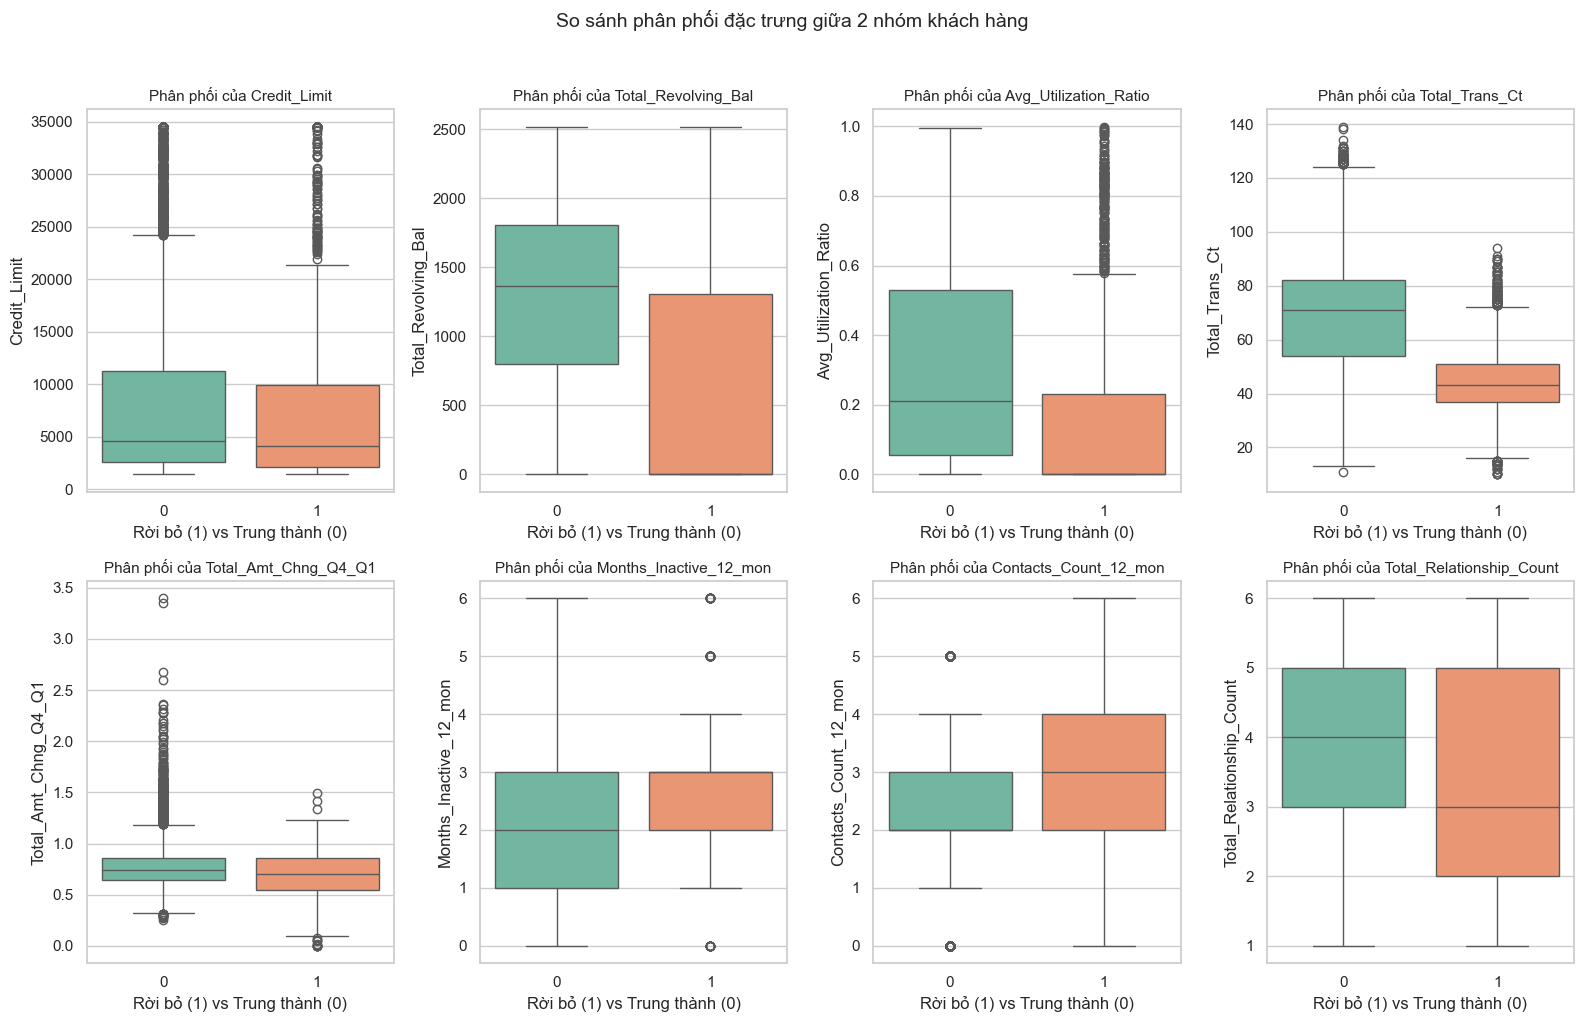

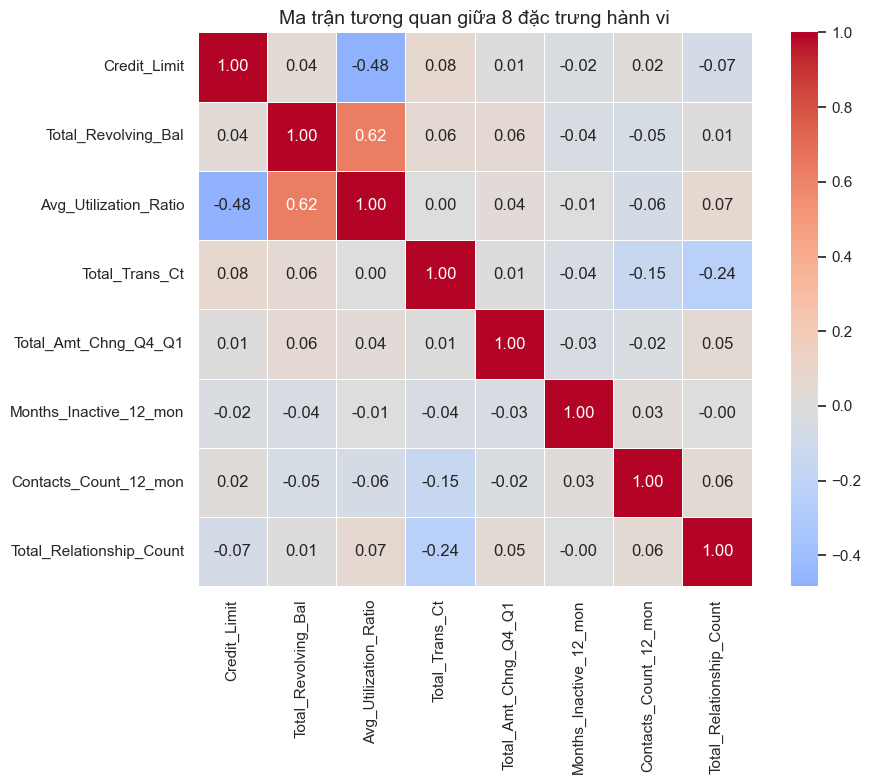

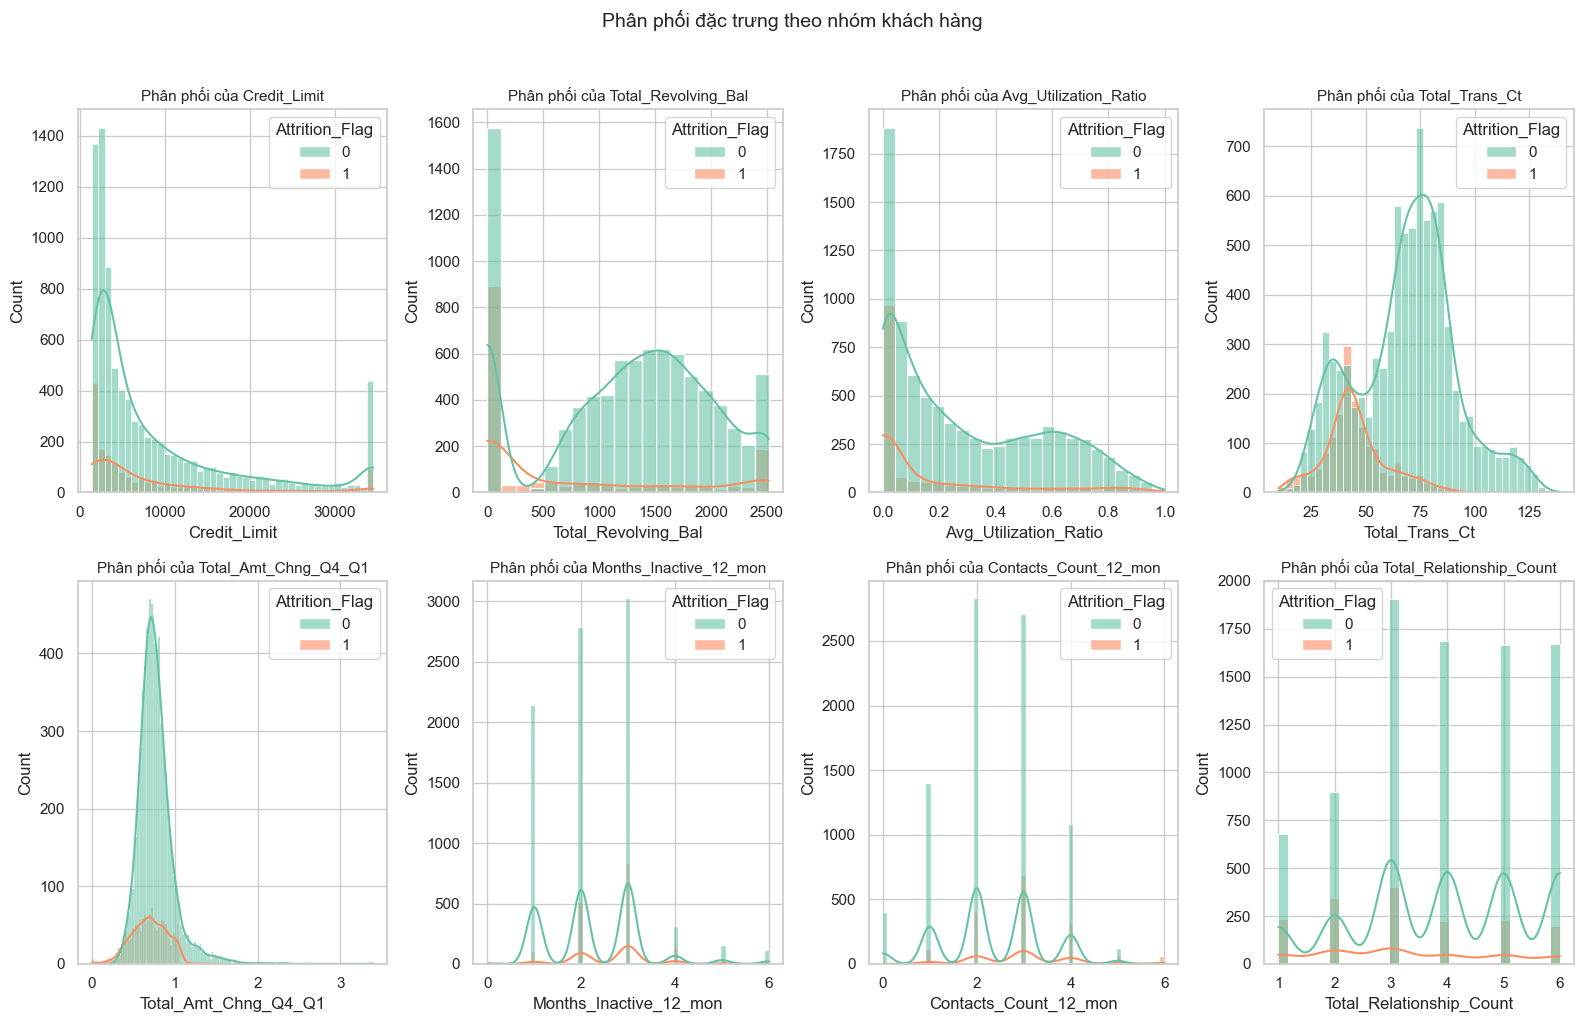

In [8]:

# 4.1 Ma trận tương quan
plt.figure(figsize=(12, 10))
corr_matrix = pd.concat([X, y], axis=1).corr()
sns.heatmap(corr_matrix, annot=True, cmap='RdYlBu', center=0, fmt='.2f', 
            square=True, linewidths=0.5)
plt.title('Ma trận tương quan giữa các đặc trưng và biến mục tiêu', fontsize=14)
plt.tight_layout()
plt.show()

# 4.2 Phân phối đặc trưng theo nhóm churn
fig, axes = plt.subplots(2, 4, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(features):
    sns.boxplot(data=df, x='Attrition_Flag', y=col, ax=axes[i], palette='Set2')
    axes[i].set_title(f'Phân phối của {col}', fontsize=11)
    axes[i].set_xlabel('Rời bỏ (1) vs Trung thành (0)')

plt.suptitle('So sánh phân phối đặc trưng giữa 2 nhóm khách hàng', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# 4.3 Heatmap tương quan giữa các đặc trưng
plt.figure(figsize=(10, 8))
sns.heatmap(X.corr(), annot=True, cmap='coolwarm', center=0, fmt='.2f', 
            square=True, linewidths=0.5)
plt.title('Ma trận tương quan giữa 8 đặc trưng hành vi', fontsize=14)
plt.tight_layout()
plt.show()

# 4.4 Phân phối của từng đặc trưng
fig, axes = plt.subplots(2, 4, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(features):
    sns.histplot(data=df, x=col, hue='Attrition_Flag', ax=axes[i], 
                 kde=True, alpha=0.6, palette='Set2')
    axes[i].set_title(f'Phân phối của {col}', fontsize=11)

plt.suptitle('Phân phối đặc trưng theo nhóm khách hàng', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


# 5. TIỀN XỬ LÝ DỮ LIỆU

In [9]:
# Chuẩn hóa dữ liệu
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=features)

# Chia tập train/test (80-20) với stratified để giữ tỷ lệ churn
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print("\n" + "="*70)
print("PHÂN CHIA DỮ LIỆU")
print("="*70)
print(f"Tập huấn luyện: {X_train.shape[0]} mẫu")
print(f"Tập kiểm tra: {X_test.shape[0]} mẫu")
print(f"Tỷ lệ churn tập train: {y_train.mean()*100:.2f}%")
print(f"Tỷ lệ churn tập test: {y_test.mean()*100:.2f}%")



PHÂN CHIA DỮ LIỆU
Tập huấn luyện: 8101 mẫu
Tập kiểm tra: 2026 mẫu
Tỷ lệ churn tập train: 16.07%
Tỷ lệ churn tập test: 16.04%


# 6. THUẬT TOÁN 1: LOGISTIC REGRESSION

In [14]:
print("\n" + "="*70)
print("THUẬT TOÁN 1: LOGISTIC REGRESSION")
print("="*70)

# Grid Search cho Logistic Regression
param_grid_lr = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear', 'saga'],
    'class_weight': ['balanced', None],
    'max_iter': [1000]
}

lr_base = LogisticRegression(random_state=42)

print(" Đang tìm tham số tối ưu cho Logistic Regression...")
grid_lr = GridSearchCV(lr_base, param_grid_lr, cv=5, scoring='roc_auc', n_jobs=-1, verbose=0)
grid_lr.fit(X_train, y_train)

print(f"\n Tham số tối ưu: {grid_lr.best_params_}")
print(f" Best CV Score (ROC-AUC): {grid_lr.best_score_:.4f}")

# Huấn luyện mô hình với tham số tối ưu
lr_best = grid_lr.best_estimator_
lr_best.fit(X_train, y_train)

# Dự đoán
y_pred_lr = lr_best.predict(X_test)
y_pred_proba_lr = lr_best.predict_proba(X_test)[:, 1]

# Đánh giá
lr_metrics = {
    'Accuracy': accuracy_score(y_test, y_pred_lr),
    'Precision': precision_score(y_test, y_pred_lr),
    'Recall': recall_score(y_test, y_pred_lr),
    'F1-Score': f1_score(y_test, y_pred_lr),
    'ROC-AUC': roc_auc_score(y_test, y_pred_proba_lr)
}

print("\n KẾT QUẢ LOGISTIC REGRESSION:")
for metric, value in lr_metrics.items():
    print(f"   • {metric}: {value:.4f}")

# Cross-validation scores
cv_scores_lr = cross_val_score(lr_best, X_scaled, y, cv=5, scoring='roc_auc')
print(f"\n Cross-validation ROC-AUC: {cv_scores_lr.mean():.4f} (+/- {cv_scores_lr.std():.4f})")

# Hệ số hồi quy (coefficients)
lr_coefficients = pd.DataFrame({
    'Đặc trưng': features,
    'Hệ số (Coefficient)': lr_best.coef_[0],
    '|Hệ số|': np.abs(lr_best.coef_[0])
}).sort_values('|Hệ số|', ascending=False)

print("\n Đặc trưng ảnh hưởng nhất (Logistic Regression):")
display(lr_coefficients)


THUẬT TOÁN 1: LOGISTIC REGRESSION
 Đang tìm tham số tối ưu cho Logistic Regression...

 Tham số tối ưu: {'C': 0.1, 'class_weight': 'balanced', 'max_iter': 1000, 'penalty': 'l1', 'solver': 'liblinear'}
 Best CV Score (ROC-AUC): 0.8924

 KẾT QUẢ LOGISTIC REGRESSION:
   • Accuracy: 0.8080
   • Precision: 0.4429
   • Recall: 0.7631
   • F1-Score: 0.5605
   • ROC-AUC: 0.8744

 Cross-validation ROC-AUC: 0.9021 (+/- 0.0448)

 Đặc trưng ảnh hưởng nhất (Logistic Regression):


,Đặc trưng,Hệ số (Coefficient),|Hệ số|
3,Total_Trans_Ct,-1.581563,1.581563
7,Total_Relationship_Count,-0.706560,0.706560
1,Total_Revolving_Bal,-0.546960,0.546960
6,Contacts_Count_12_mon,0.513209,0.513209
5,Months_Inactive_12_mon,0.503037,0.503037
4,Total_Amt_Chng_Q4_Q1,-0.209358,0.209358
2,Avg_Utilization_Ratio,-0.158918,0.158918
0,Credit_Limit,0.000000,0.000000


# 7. THUẬT TOÁN 2: DECISION TREE


THUẬT TOÁN 2: DECISION TREE
 Đang tìm tham số tối ưu cho Decision Tree...

 Tham số tối ưu: {'class_weight': None, 'criterion': 'entropy', 'max_depth': 7, 'min_samples_leaf': 8, 'min_samples_split': 20}
 Best CV Score (ROC-AUC): 0.9237

 KẾT QUẢ DECISION TREE:
   • Accuracy: 0.9038
   • Precision: 0.7321
   • Recall: 0.6308
   • F1-Score: 0.6777
   • ROC-AUC: 0.9063

 Cross-validation ROC-AUC: 0.8676 (+/- 0.1174)


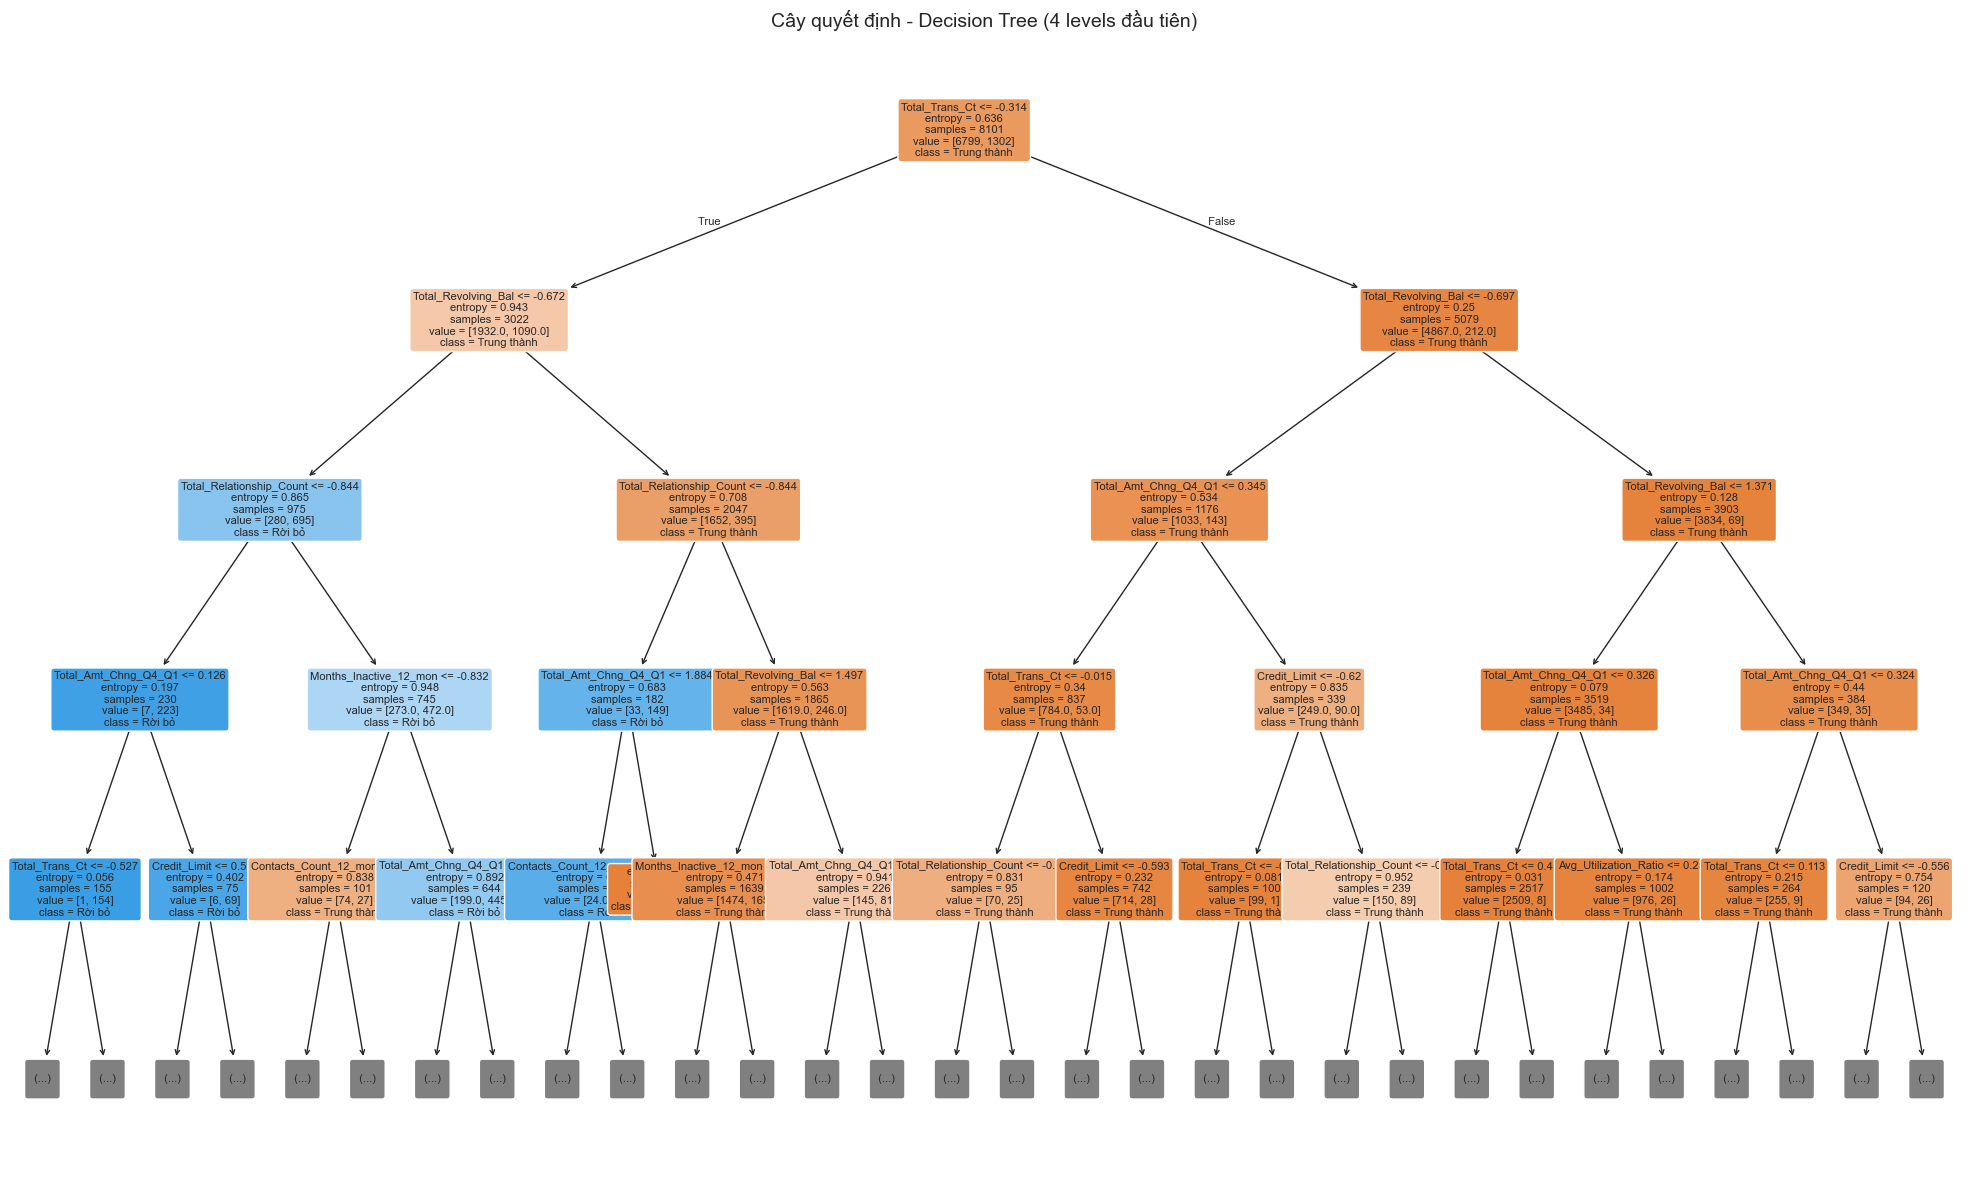


 Top đặc trưng quan trọng nhất (Decision Tree):


,Đặc trưng,Importance
3,Total_Trans_Ct,0.387859
1,Total_Revolving_Bal,0.269173
7,Total_Relationship_Count,0.146691
4,Total_Amt_Chng_Q4_Q1,0.093166
0,Credit_Limit,0.053008
5,Months_Inactive_12_mon,0.032744
6,Contacts_Count_12_mon,0.010067
2,Avg_Utilization_Ratio,0.007292


In [13]:

print("\n" + "="*70)
print("THUẬT TOÁN 2: DECISION TREE")
print("="*70)

# Grid Search cho Decision Tree
param_grid_dt = {
    'max_depth': [3, 5, 7, 10, 15, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 4, 8],
    'criterion': ['gini', 'entropy'],
    'class_weight': ['balanced', None]
}

dt_base = DecisionTreeClassifier(random_state=42)

print(" Đang tìm tham số tối ưu cho Decision Tree...")
grid_dt = GridSearchCV(dt_base, param_grid_dt, cv=5, scoring='roc_auc', n_jobs=-1, verbose=0)
grid_dt.fit(X_train, y_train)

print(f"\n Tham số tối ưu: {grid_dt.best_params_}")
print(f" Best CV Score (ROC-AUC): {grid_dt.best_score_:.4f}")

# Huấn luyện mô hình với tham số tối ưu
dt_best = grid_dt.best_estimator_
dt_best.fit(X_train, y_train)

# Dự đoán
y_pred_dt = dt_best.predict(X_test)
y_pred_proba_dt = dt_best.predict_proba(X_test)[:, 1]

# Đánh giá
dt_metrics = {
    'Accuracy': accuracy_score(y_test, y_pred_dt),
    'Precision': precision_score(y_test, y_pred_dt),
    'Recall': recall_score(y_test, y_pred_dt),
    'F1-Score': f1_score(y_test, y_pred_dt),
    'ROC-AUC': roc_auc_score(y_test, y_pred_proba_dt)
}

print("\n KẾT QUẢ DECISION TREE:")
for metric, value in dt_metrics.items():
    print(f"   • {metric}: {value:.4f}")

# Cross-validation scores
cv_scores_dt = cross_val_score(dt_best, X_scaled, y, cv=5, scoring='roc_auc')
print(f"\n Cross-validation ROC-AUC: {cv_scores_dt.mean():.4f} (+/- {cv_scores_dt.std():.4f})")

# Vẽ cây quyết định
plt.figure(figsize=(20, 12))
plot_tree(dt_best, max_depth=4, feature_names=features, 
          class_names=['Trung thành', 'Rời bỏ'], 
          filled=True, rounded=True, fontsize=8)
plt.title('Cây quyết định - Decision Tree (4 levels đầu tiên)', fontsize=14)
plt.tight_layout()
plt.show()

# Feature Importance từ Decision Tree
dt_feature_importance = pd.DataFrame({
    'Đặc trưng': features,
    'Importance': dt_best.feature_importances_
}).sort_values('Importance', ascending=False)

print("\n Top đặc trưng quan trọng nhất (Decision Tree):")
display(dt_feature_importance)

# 8. THUẬT TOÁN 3: SVM (SUPPORT VECTOR MACHINE)

In [17]:
print("\n" + "="*70)
print("THUẬT TOÁN 3: SVM - SUPPORT VECTOR MACHINE (TỐI ƯU NHANH)")
print("="*70)

# SỬ DỤNG RANDOMIZED SEARCH (NHANH HƠN GridSearch)
from sklearn.model_selection import RandomizedSearchCV
from sklearn.inspection import permutation_importance
import time

# Giới hạn tham số để chạy nhanh hơn
param_dist_svm = {
    'C': [0.1, 1, 10],  # Giảm số lượng
    'gamma': ['scale', 0.1, 1],  # Giảm số lượng
    'kernel': ['rbf'],  # Chỉ dùng rbf (tốt nhất cho dữ liệu này)
    'class_weight': ['balanced', None]
}

svm_base = SVC(probability=True, random_state=42)

print(" Đang tìm tham số tối ưu cho SVM (RandomizedSearch - nhanh hơn)...")
start_time = time.time()
random_search_svm = RandomizedSearchCV(
    svm_base, param_dist_svm, n_iter=10,  # Chỉ thử 10 tổ hợp tham số
    cv=3, scoring='roc_auc', n_jobs=-1, random_state=42, verbose=0
)
random_search_svm.fit(X_train, y_train)
elapsed_time = time.time() - start_time

print(f"\n Tham số tối ưu: {random_search_svm.best_params_}")
print(f" Best CV Score (ROC-AUC): {random_search_svm.best_score_:.4f}")
print(f" Thời gian chạy: {elapsed_time:.1f} giây")

# Huấn luyện mô hình với tham số tối ưu
svm_best = random_search_svm.best_estimator_
svm_best.fit(X_train, y_train)

# Dự đoán
y_pred_svm = svm_best.predict(X_test)
y_pred_proba_svm = svm_best.predict_proba(X_test)[:, 1]

# Đánh giá
svm_metrics = {
    'Accuracy': accuracy_score(y_test, y_pred_svm),
    'Precision': precision_score(y_test, y_pred_svm),
    'Recall': recall_score(y_test, y_pred_svm),
    'F1-Score': f1_score(y_test, y_pred_svm),
    'ROC-AUC': roc_auc_score(y_test, y_pred_proba_svm)
}

print("\n KẾT QUẢ SVM:")
for metric, value in svm_metrics.items():
    print(f"   • {metric}: {value:.4f}")

# Cross-validation scores
cv_scores_svm = cross_val_score(svm_best, X_scaled, y, cv=5, scoring='roc_auc')
print(f"\n Cross-validation ROC-AUC: {cv_scores_svm.mean():.4f} (+/- {cv_scores_svm.std():.4f})")


THUẬT TOÁN 3: SVM - SUPPORT VECTOR MACHINE (TỐI ƯU NHANH)
 Đang tìm tham số tối ưu cho SVM (RandomizedSearch - nhanh hơn)...

 Tham số tối ưu: {'kernel': 'rbf', 'gamma': 0.1, 'class_weight': None, 'C': 10}
 Best CV Score (ROC-AUC): 0.9468
 Thời gian chạy: 25.3 giây

 KẾT QUẢ SVM:
   • Accuracy: 0.9116
   • Precision: 0.7944
   • Recall: 0.6062
   • F1-Score: 0.6876
   • ROC-AUC: 0.9211

 Cross-validation ROC-AUC: 0.9203 (+/- 0.0428)


# 9. SO SÁNH 3 THUẬT TOÁN

In [18]:
print("\n" + "="*70)
print("SO SÁNH 3 THUẬT TOÁN PHÂN LỚP")
print("="*70)

# Tạo bảng so sánh
comparison_df = pd.DataFrame({
    'Thuật toán': ['Logistic Regression', 'Decision Tree', 'SVM'],
    'Accuracy': [lr_metrics['Accuracy'], dt_metrics['Accuracy'], svm_metrics['Accuracy']],
    'Precision': [lr_metrics['Precision'], dt_metrics['Precision'], svm_metrics['Precision']],
    'Recall': [lr_metrics['Recall'], dt_metrics['Recall'], svm_metrics['Recall']],
    'F1-Score': [lr_metrics['F1-Score'], dt_metrics['F1-Score'], svm_metrics['F1-Score']],
    'ROC-AUC': [lr_metrics['ROC-AUC'], dt_metrics['ROC-AUC'], svm_metrics['ROC-AUC']]
})

display(comparison_df)


SO SÁNH 3 THUẬT TOÁN PHÂN LỚP


,Thuật toán,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.807996,0.442857,0.763077,0.560452,0.874356
1,Decision Tree,0.903751,0.732143,0.630769,0.677686,0.906307
2,SVM,0.911649,0.794355,0.606154,0.687609,0.921092


# 10. TRỰC QUAN HÓA SO SÁNH KẾT QUẢ

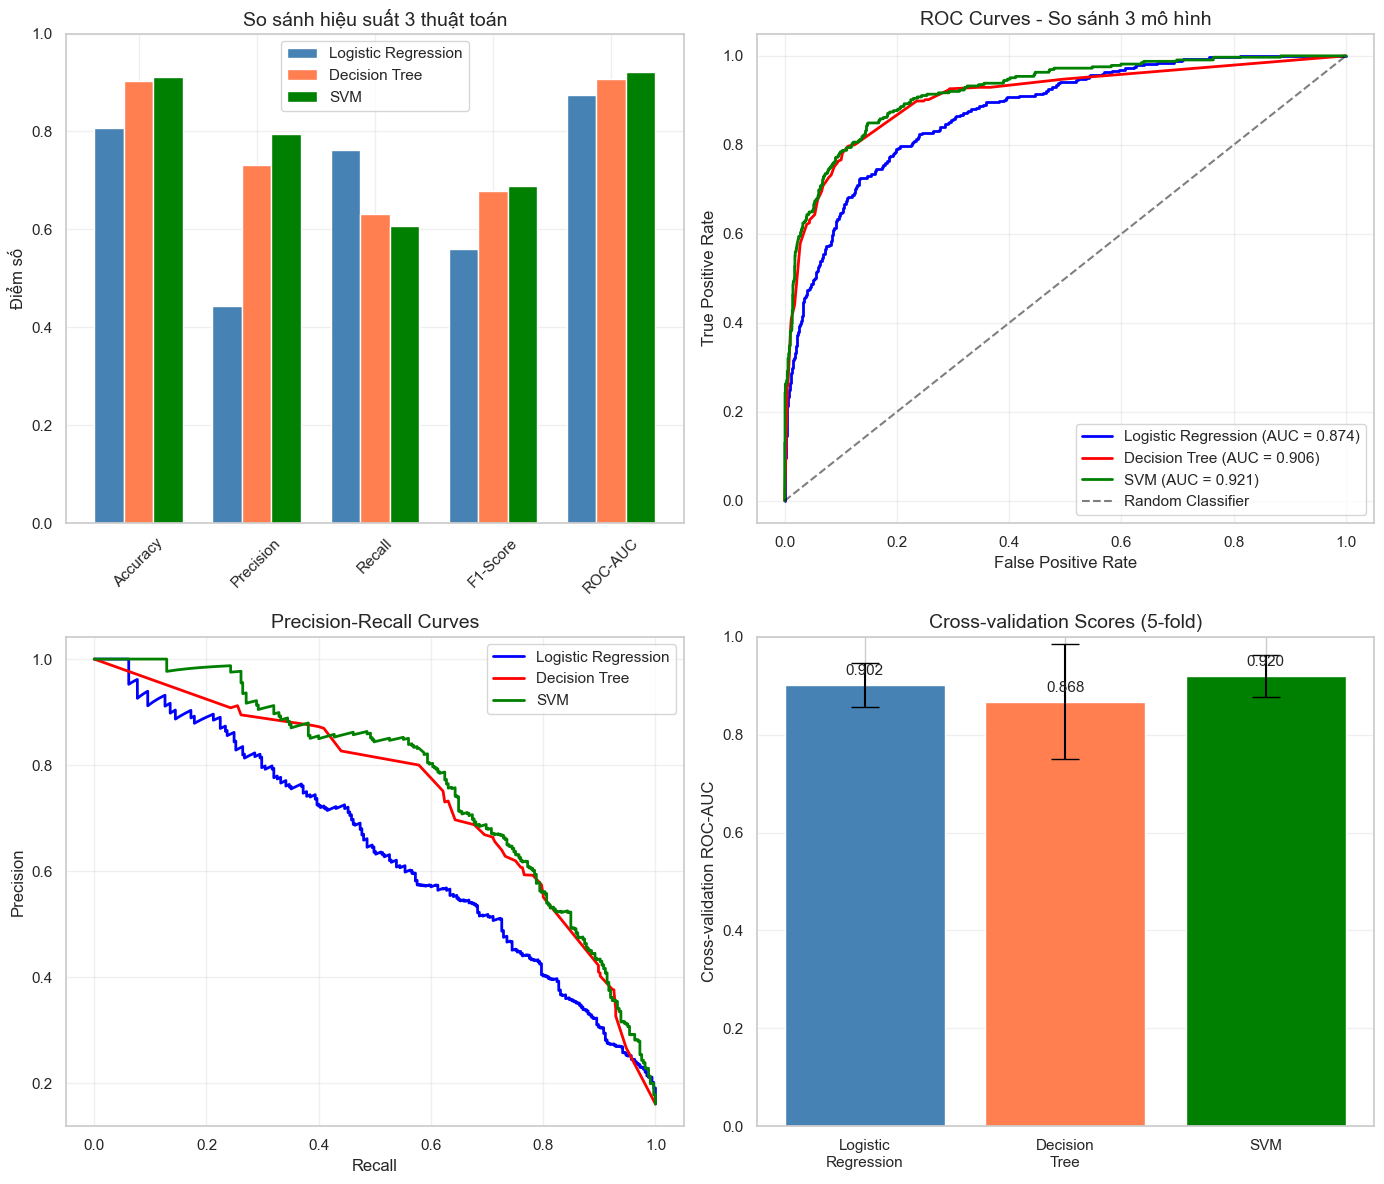

In [19]:
# 10.1 Biểu đồ so sánh các metrics
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# 1. So sánh các metrics
metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
lr_values = [lr_metrics[m] for m in metrics_names]
dt_values = [dt_metrics[m] for m in metrics_names]
svm_values = [svm_metrics[m] for m in metrics_names]

x = np.arange(len(metrics_names))
width = 0.25

axes[0, 0].bar(x - width, lr_values, width, label='Logistic Regression', color='steelblue')
axes[0, 0].bar(x, dt_values, width, label='Decision Tree', color='coral')
axes[0, 0].bar(x + width, svm_values, width, label='SVM', color='green')
axes[0, 0].set_ylabel('Điểm số', fontsize=12)
axes[0, 0].set_title('So sánh hiệu suất 3 thuật toán', fontsize=14)
axes[0, 0].set_xticks(x)
axes[0, 0].set_xticklabels(metrics_names, rotation=45)
axes[0, 0].legend()
axes[0, 0].set_ylim(0, 1)
axes[0, 0].grid(True, alpha=0.3)

# 2. ROC Curves
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_pred_proba_lr)
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_pred_proba_dt)
fpr_svm, tpr_svm, _ = roc_curve(y_test, y_pred_proba_svm)

axes[0, 1].plot(fpr_lr, tpr_lr, 'b-', linewidth=2, label=f'Logistic Regression (AUC = {lr_metrics["ROC-AUC"]:.3f})')
axes[0, 1].plot(fpr_dt, tpr_dt, 'r-', linewidth=2, label=f'Decision Tree (AUC = {dt_metrics["ROC-AUC"]:.3f})')
axes[0, 1].plot(fpr_svm, tpr_svm, 'g-', linewidth=2, label=f'SVM (AUC = {svm_metrics["ROC-AUC"]:.3f})')
axes[0, 1].plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random Classifier')
axes[0, 1].set_xlabel('False Positive Rate', fontsize=12)
axes[0, 1].set_ylabel('True Positive Rate', fontsize=12)
axes[0, 1].set_title('ROC Curves - So sánh 3 mô hình', fontsize=14)
axes[0, 1].legend(loc='lower right')
axes[0, 1].grid(True, alpha=0.3)

# 3. Precision-Recall Curves
precision_lr, recall_lr, _ = precision_recall_curve(y_test, y_pred_proba_lr)
precision_dt, recall_dt, _ = precision_recall_curve(y_test, y_pred_proba_dt)
precision_svm, recall_svm, _ = precision_recall_curve(y_test, y_pred_proba_svm)

axes[1, 0].plot(recall_lr, precision_lr, 'b-', linewidth=2, label='Logistic Regression')
axes[1, 0].plot(recall_dt, precision_dt, 'r-', linewidth=2, label='Decision Tree')
axes[1, 0].plot(recall_svm, precision_svm, 'g-', linewidth=2, label='SVM')
axes[1, 0].set_xlabel('Recall', fontsize=12)
axes[1, 0].set_ylabel('Precision', fontsize=12)
axes[1, 0].set_title('Precision-Recall Curves', fontsize=14)
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# 4. Cross-validation scores
cv_means = [cv_scores_lr.mean(), cv_scores_dt.mean(), cv_scores_svm.mean()]
cv_stds = [cv_scores_lr.std(), cv_scores_dt.std(), cv_scores_svm.std()]
models = ['Logistic\nRegression', 'Decision\nTree', 'SVM']

axes[1, 1].bar(models, cv_means, yerr=cv_stds, capsize=10, color=['steelblue', 'coral', 'green'])
axes[1, 1].set_ylabel('Cross-validation ROC-AUC', fontsize=12)
axes[1, 1].set_title('Cross-validation Scores (5-fold)', fontsize=14)
axes[1, 1].set_ylim(0, 1)
axes[1, 1].grid(True, alpha=0.3, axis='y')

for i, (mean, std) in enumerate(zip(cv_means, cv_stds)):
    axes[1, 1].text(i, mean + 0.02, f'{mean:.3f}', ha='center', fontsize=11)

plt.tight_layout()
plt.show()


# 11. CONFUSION MATRICES CHO 3 MÔ HÌNH

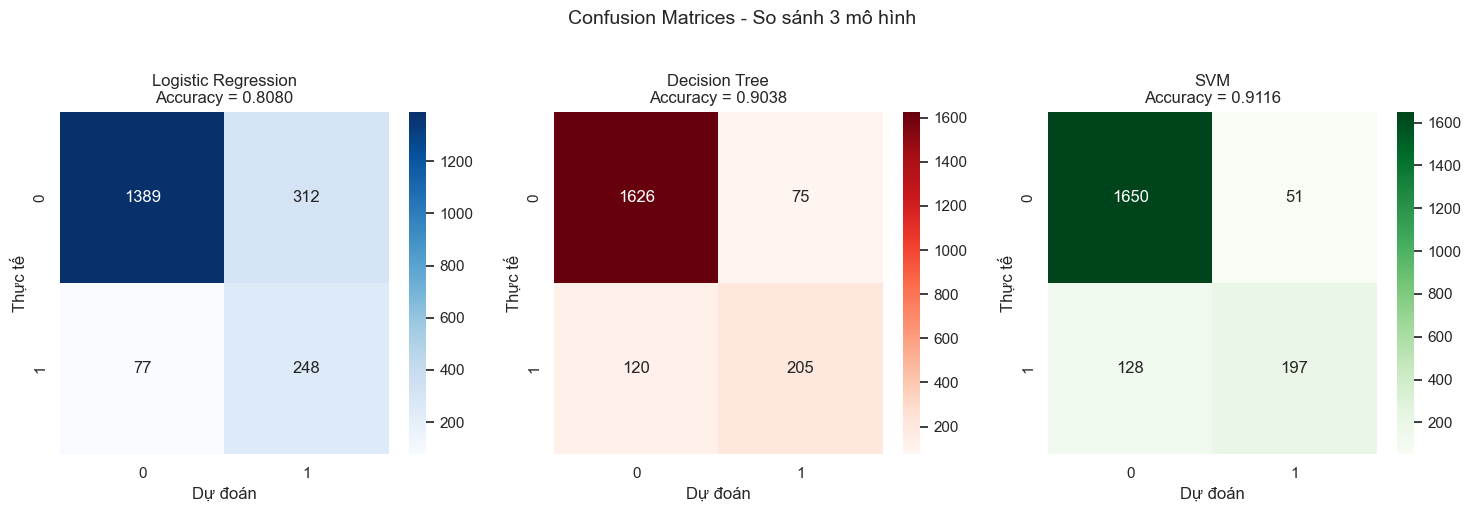

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Logistic Regression
cm_lr = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_xlabel('Dự đoán', fontsize=12)
axes[0].set_ylabel('Thực tế', fontsize=12)
axes[0].set_title(f'Logistic Regression\nAccuracy = {lr_metrics["Accuracy"]:.4f}', fontsize=12)

# Decision Tree
cm_dt = confusion_matrix(y_test, y_pred_dt)
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Reds', ax=axes[1])
axes[1].set_xlabel('Dự đoán', fontsize=12)
axes[1].set_ylabel('Thực tế', fontsize=12)
axes[1].set_title(f'Decision Tree\nAccuracy = {dt_metrics["Accuracy"]:.4f}', fontsize=12)

# SVM
cm_svm = confusion_matrix(y_test, y_pred_svm)
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Greens', ax=axes[2])
axes[2].set_xlabel('Dự đoán', fontsize=12)
axes[2].set_ylabel('Thực tế', fontsize=12)
axes[2].set_title(f'SVM\nAccuracy = {svm_metrics["Accuracy"]:.4f}', fontsize=12)

plt.suptitle('Confusion Matrices - So sánh 3 mô hình', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


# 12. LEARNING CURVES ĐÁNH GIÁ OVERFITTING


ĐÁNH GIÁ OVERFITTING - LEARNING CURVES


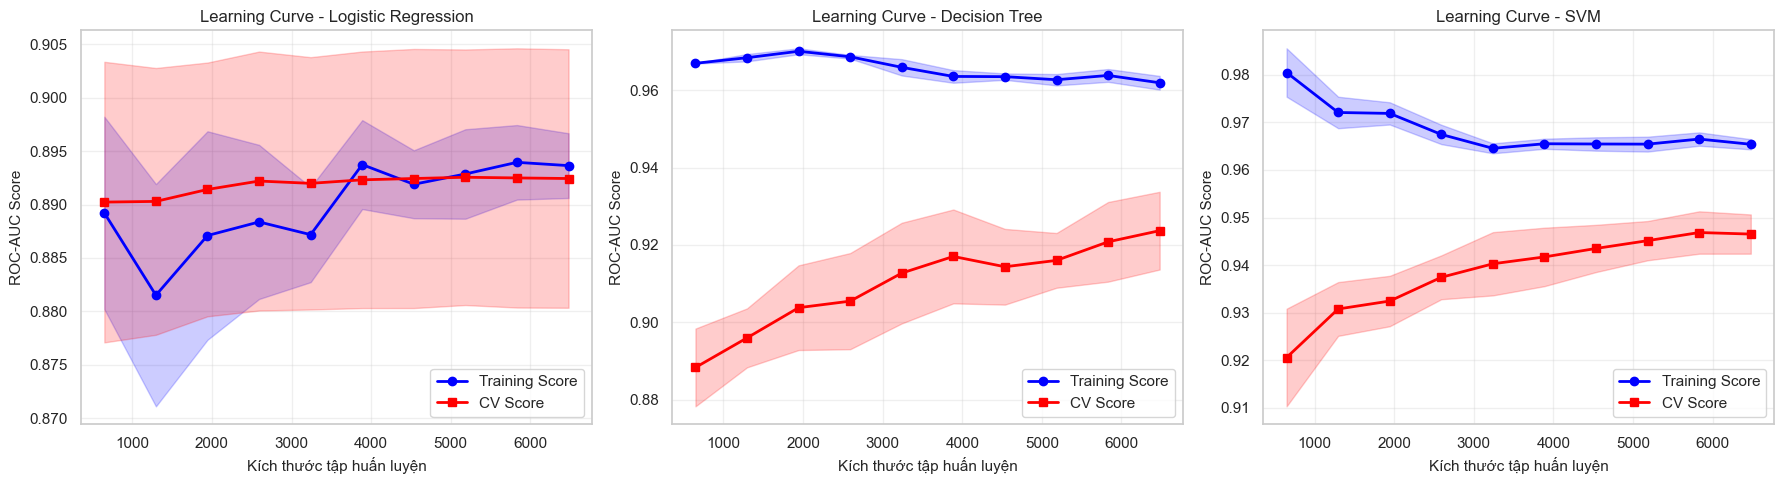

In [21]:
print("\n" + "="*70)
print("ĐÁNH GIÁ OVERFITTING - LEARNING CURVES")
print("="*70)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

models_for_curve = [
    ('Logistic Regression', lr_best),
    ('Decision Tree', dt_best),
    ('SVM', svm_best)
]

for idx, (name, model) in enumerate(models_for_curve):
    train_sizes, train_scores, test_scores = learning_curve(
        model, X_train, y_train, cv=5, n_jobs=-1,
        train_sizes=np.linspace(0.1, 1.0, 10),
        scoring='roc_auc'
    )
    
    train_mean = np.mean(train_scores, axis=1)
    train_std = np.std(train_scores, axis=1)
    test_mean = np.mean(test_scores, axis=1)
    test_std = np.std(test_scores, axis=1)
    
    axes[idx].plot(train_sizes, train_mean, 'b-o', label='Training Score', linewidth=2)
    axes[idx].fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.2, color='blue')
    axes[idx].plot(train_sizes, test_mean, 'r-s', label='CV Score', linewidth=2)
    axes[idx].fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.2, color='red')
    axes[idx].set_xlabel('Kích thước tập huấn luyện', fontsize=11)
    axes[idx].set_ylabel('ROC-AUC Score', fontsize=11)
    axes[idx].set_title(f'Learning Curve - {name}', fontsize=12)
    axes[idx].legend(loc='lower right')
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 13. SO SÁNH FEATURE IMPORTANCE


SO SÁNH ĐỘ QUAN TRỌNG CỦA ĐẶC TRƯNG


,Đặc trưng,Logistic Regression Coef (abs),Decision Tree Importance,SVM Importance (Permutation)
3,Total_Trans_Ct,1.581563,0.387859,0.097384
1,Total_Revolving_Bal,0.546960,0.269173,0.060513
7,Total_Relationship_Count,0.706560,0.146691,0.041856
4,Total_Amt_Chng_Q4_Q1,0.209358,0.093166,0.016535
0,Credit_Limit,0.000000,0.053008,0.005627
5,Months_Inactive_12_mon,0.503037,0.032744,0.007305
6,Contacts_Count_12_mon,0.513209,0.010067,0.010020
2,Avg_Utilization_Ratio,0.158918,0.007292,0.011846


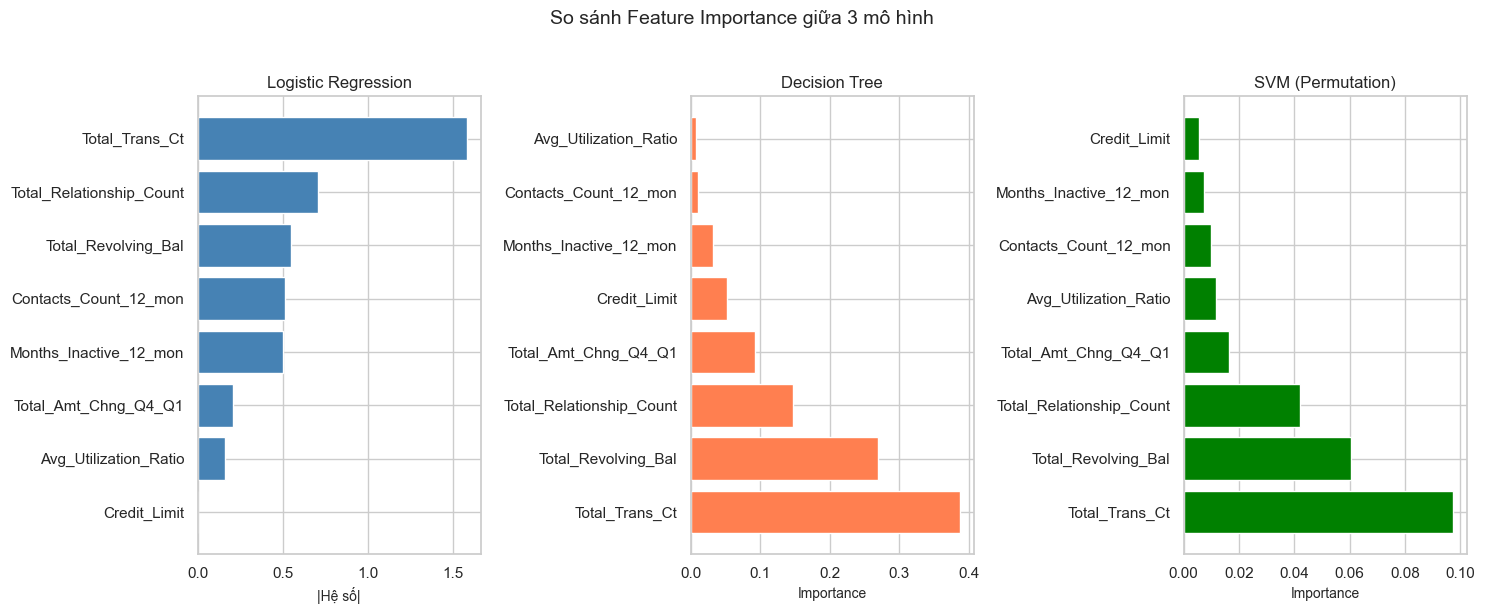

In [22]:
print("\n" + "="*70)
print("SO SÁNH ĐỘ QUAN TRỌNG CỦA ĐẶC TRƯNG")
print("="*70)

# Tính permutation importance cho SVM
perm_importance_svm = permutation_importance(svm_best, X_test, y_test, n_repeats=10, random_state=42)
svm_importance = pd.DataFrame({
    'Đặc trưng': features,
    'Importance_SVM': perm_importance_svm.importances_mean
}).sort_values('Importance_SVM', ascending=False)

# So sánh 3 phương pháp
importance_compare = pd.DataFrame({
    'Đặc trưng': features,
    'Logistic Regression Coef (abs)': np.abs(lr_best.coef_[0]),
    'Decision Tree Importance': dt_best.feature_importances_,
    'SVM Importance (Permutation)': perm_importance_svm.importances_mean
}).sort_values('Decision Tree Importance', ascending=False)

display(importance_compare)

# Vẽ biểu đồ so sánh
fig, axes = plt.subplots(1, 3, figsize=(15, 6))

# Logistic Regression
lr_imp_plot = pd.DataFrame({
    'Đặc trưng': features,
    'Importance': np.abs(lr_best.coef_[0])
}).sort_values('Importance', ascending=True)
axes[0].barh(lr_imp_plot['Đặc trưng'], lr_imp_plot['Importance'], color='steelblue')
axes[0].set_title('Logistic Regression', fontsize=12)
axes[0].set_xlabel('|Hệ số|', fontsize=10)

# Decision Tree
dt_imp_plot = dt_feature_importance
axes[1].barh(dt_imp_plot['Đặc trưng'], dt_imp_plot['Importance'], color='coral')
axes[1].set_title('Decision Tree', fontsize=12)
axes[1].set_xlabel('Importance', fontsize=10)

# SVM
svm_imp_plot = svm_importance
axes[2].barh(svm_imp_plot['Đặc trưng'], svm_imp_plot['Importance_SVM'], color='green')
axes[2].set_title('SVM (Permutation)', fontsize=12)
axes[2].set_xlabel('Importance', fontsize=10)

plt.suptitle('So sánh Feature Importance giữa 3 mô hình', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


# 14. ĐỀ XUẤT CHIẾN LƯỢC KINH DOANH

In [31]:
print("\n" + "="*70)
print(" ĐỀ XUẤT CHIẾN LƯỢC DỰA TRÊN KẾT QUẢ PHÂN TÍCH")
print("="*70)

# Xác định mô hình tốt nhất dựa trên F1-Score
best_model_name = max([
    ('Logistic Regression', lr_metrics['F1-Score']),
    ('Decision Tree', dt_metrics['F1-Score']),
    ('SVM', svm_metrics['F1-Score'])
], key=lambda x: x[1])[0]

print(f"\n MÔ HÌNH TỐT NHẤT: {best_model_name}")
print(f"   • F1-Score: {max([lr_metrics['F1-Score'], dt_metrics['F1-Score'], svm_metrics['F1-Score']]):.4f}")
print(f"   • ROC-AUC: {max([lr_metrics['ROC-AUC'], dt_metrics['ROC-AUC'], svm_metrics['ROC-AUC']]):.4f}")

# Quy tắc từ Decision Tree
print("\n" + "="*70)
print(" QUY TẮC QUYẾT ĐỊNH TỪ DECISION TREE")
print("="*70)
from sklearn.tree import export_text
tree_rules = export_text(dt_best, feature_names=features, max_depth=3)
print(tree_rules)

print("\n" + "="*70)
print(" KHUYẾN NGHỊ HÀNH ĐỘNG")
print("="*70)

recommendations = {
    'Chiến lược tổng thể': [
        ' Sử dụng mô hình Logistic Regression để giải thích và triển khai nhanh',
        ' Sử dụng Decision Tree để có quy tắc trực quan cho nhân viên kinh doanh',
        ' Sử dụng SVM khi cần độ chính xác cao nhất (tuy chậm hơn)'
    ],
    'Phân loại khách hàng theo nguy cơ': [
        ' Nguy cơ cao (proba > 0.7): Can thiệp ngay - gọi điện chăm sóc đặc biệt',
        ' Nguy cơ trung bình (0.3 < proba ≤ 0.7): Gửi ưu đãi giữ chân qua email/SMS',
        ' Nguy cơ thấp (proba ≤ 0.3): Duy trì chăm sóc bình thường'
    ],
    'Các yếu tố ảnh hưởng nhiều nhất đến rời bỏ': [
        f'   • {dt_feature_importance.iloc[0]["Đặc trưng"]}: {dt_feature_importance.iloc[0]["Importance"]:.3f}',
        f'   • {dt_feature_importance.iloc[1]["Đặc trưng"]}: {dt_feature_importance.iloc[1]["Importance"]:.3f}',
        f'   • {dt_feature_importance.iloc[2]["Đặc trưng"]}: {dt_feature_importance.iloc[2]["Importance"]:.3f}'
    ]
}

for category, actions in recommendations.items():
    print(f"\n {category}:")
    for action in actions:
        print(f"   {action}")


 ĐỀ XUẤT CHIẾN LƯỢC DỰA TRÊN KẾT QUẢ PHÂN TÍCH

 MÔ HÌNH TỐT NHẤT: SVM
   • F1-Score: 0.6876
   • ROC-AUC: 0.9211

 QUY TẮC QUYẾT ĐỊNH TỪ DECISION TREE
|--- Total_Trans_Ct <= -0.31
|   |--- Total_Revolving_Bal <= -0.67
|   |   |--- Total_Relationship_Count <= -0.84
|   |   |   |--- Total_Amt_Chng_Q4_Q1 <= 0.13
|   |   |   |   |--- truncated branch of depth 2
|   |   |   |--- Total_Amt_Chng_Q4_Q1 >  0.13
|   |   |   |   |--- truncated branch of depth 3
|   |   |--- Total_Relationship_Count >  -0.84
|   |   |   |--- Months_Inactive_12_mon <= -0.83
|   |   |   |   |--- truncated branch of depth 4
|   |   |   |--- Months_Inactive_12_mon >  -0.83
|   |   |   |   |--- truncated branch of depth 4
|   |--- Total_Revolving_Bal >  -0.67
|   |   |--- Total_Relationship_Count <= -0.84
|   |   |   |--- Total_Amt_Chng_Q4_Q1 <= 1.88
|   |   |   |   |--- truncated branch of depth 4
|   |   |   |--- Total_Amt_Chng_Q4_Q1 >  1.88
|   |   |   |   |--- class: 0
|   |   |--- Total_Relationship_Count >  -0.

# 15. DỰ ĐOÁN TRÊN DỮ LIỆU MỚI (DEMO)

In [33]:

print("\n" + "="*70)
print("DEMO DỰ ĐOÁN TRÊN DỮ LIỆU MỚI")
print("="*70)

# Tạo dữ liệu mẫu cho 3 khách hàng giả định
new_customers = pd.DataFrame([
    {   # Khách hàng trung thành
        'Credit_Limit': 25000, 'Total_Revolving_Bal': 500, 'Avg_Utilization_Ratio': 0.15,
        'Total_Trans_Ct': 85, 'Total_Amt_Chng_Q4_Q1': 1.5, 'Months_Inactive_12_mon': 0,
        'Contacts_Count_12_mon': 1, 'Total_Relationship_Count': 5
    },
    {   # Khách hàng nguy cơ trung bình
        'Credit_Limit': 8000, 'Total_Revolving_Bal': 2000, 'Avg_Utilization_Ratio': 0.65,
        'Total_Trans_Ct': 35, 'Total_Amt_Chng_Q4_Q1': 0.7, 'Months_Inactive_12_mon': 2,
        'Contacts_Count_12_mon': 3, 'Total_Relationship_Count': 3
    },
    {   # Khách hàng nguy cơ cao
        'Credit_Limit': 3000, 'Total_Revolving_Bal': 2800, 'Avg_Utilization_Ratio': 0.95,
        'Total_Trans_Ct': 15, 'Total_Amt_Chng_Q4_Q1': 0.3, 'Months_Inactive_12_mon': 5,
        'Contacts_Count_12_mon': 5, 'Total_Relationship_Count': 1
    }
])

# Chuẩn hóa dữ liệu mới
new_customers_scaled = scaler.transform(new_customers)

# Dự đoán bằng 3 mô hình
new_proba_lr = lr_best.predict_proba(new_customers_scaled)[:, 1]
new_proba_dt = dt_best.predict_proba(new_customers_scaled)[:, 1]
new_proba_svm = svm_best.predict_proba(new_customers_scaled)[:, 1]

print("\n KẾT QUẢ DỰ ĐOÁN CHO 3 KHÁCH HÀNG MẪU:")
demo_results = pd.DataFrame({
    'Khách hàng': ['KH_Trung thành', 'KH_Nguy cơ TB', 'KH_Nguy cơ cao'],
    'Logistic Regression': [f'{p*100:.1f}%' for p in new_proba_lr],
    'Decision Tree': [f'{p*100:.1f}%' for p in new_proba_dt],
    'SVM': [f'{p*100:.1f}%' for p in new_proba_svm],
    'Kết luận': [
        ' Trung thành - Duy trì chăm sóc',
        ' Nguy cơ TB - Gửi ưu đãi',
        ' Nguy cơ CAO - Can thiệp ngay!'
    ]
})
display(demo_results)


DEMO DỰ ĐOÁN TRÊN DỮ LIỆU MỚI

 KẾT QUẢ DỰ ĐOÁN CHO 3 KHÁCH HÀNG MẪU:


,Khách hàng,Logistic Regression,Decision Tree,SVM,Kết luận
0,KH_Trung thành,0.7%,0.0%,16.4%,Trung thành - Duy trì chăm sóc
1,KH_Nguy cơ TB,67.0%,11.7%,10.7%,Nguy cơ TB - Gửi ưu đãi
2,KH_Nguy cơ cao,99.4%,100.0%,96.8%,Nguy cơ CAO - Can thiệp ngay!
